<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import label as nd_label
from skimage.measure import regionprops
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
def laplacian(Z):
    return (
        -1 * Z
        + 0.2 * (
            np.roll(Z, 1, 0) +
            np.roll(Z, -1, 0) +
            np.roll(Z, 1, 1) +
            np.roll(Z, -1, 1)
        )
        + 0.05 * (
            np.roll(np.roll(Z, 1, 0), 1, 1) +
            np.roll(np.roll(Z, 1, 0), -1, 1) +
            np.roll(np.roll(Z, -1, 0), 1, 1) +
            np.roll(np.roll(Z, -1, 0), -1, 1)
        )
    )

In [3]:
def run_gray_scott(n=96, steps=1500, feed=0.035, kill=0.065, seed=0):
    np.random.seed(seed)

    A = np.ones((n, n))
    B = np.zeros((n, n))

    r = 8
    c = n // 2

    A[c-r:c+r, c-r:c+r] = 0.5
    B[c-r:c+r, c-r:c+r] = 0.25

    B += 0.05 * np.random.random((n, n))

    for _ in range(steps):
        reaction = A * B * B
        A += laplacian(A) - reaction + feed * (1 - A)
        B += 0.5 * laplacian(B) + reaction - (kill + feed) * B

    return A, B

In [4]:
def pattern_features(B):
    threshold = np.percentile(B, 60)
    binary = B > threshold

    labeled, count = nd_label(binary)
    props = regionprops(labeled)

    areas = []
    roundness = []
    elongation = []

    for p in props:
        if p.area < 5:
            continue

        areas.append(p.area)

        perimeter = max(p.perimeter, 1e-6)
        roundness.append(4 * np.pi * p.area / (perimeter ** 2))

        if p.minor_axis_length > 1e-6:
            elongation.append(p.major_axis_length / p.minor_axis_length)
        else:
            elongation.append(0)

    gy, gx = np.gradient(B)
    flow = np.mean(np.sqrt(gx**2 + gy**2))

    return {
        "count": len(areas),
        "avg_area": float(np.mean(areas)) if areas else 0.0,
        "roundness": float(np.mean(roundness)) if roundness else 0.0,
        "elongation": float(np.mean(elongation)) if elongation else 0.0,
        "density": float(np.mean(binary)),
        "structure": float(np.std(B)),
        "flow": float(flow),
    }

In [5]:
N = 120

patterns = []
features = []
params = []

np.random.seed(42)

for i in range(N):
    feed = np.random.uniform(0.025, 0.060)
    kill = np.random.uniform(0.050, 0.070)

    A, B = run_gray_scott(feed=feed, kill=kill, seed=i)
    f = pattern_features(B)

    patterns.append(B)
    features.append(f)
    params.append((feed, kill))

print("generated:", len(patterns))

generated: 120


In [6]:
feature_names = [
    "count",
    "avg_area",
    "roundness",
    "elongation",
    "density",
    "structure",
    "flow",
]

X = np.array([[f[k] for k in feature_names] for f in features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("clusters:", sorted(set(clusters)))

clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]



SYMBOL: A
count: 52
count       : 1.0385
avg_area    : 3638.5705
roundness   : 0.7923
elongation  : 1.0155
density     : 0.3999
structure   : 0.0131
flow        : 0.0011


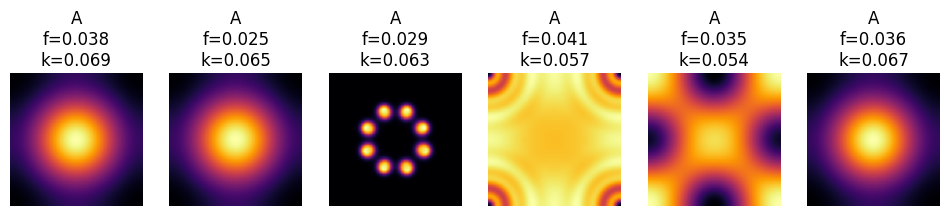


SYMBOL: B
count: 19
count       : 8.2105
avg_area    : 536.3247
roundness   : 0.6001
elongation  : 1.8978
density     : 0.4000
structure   : 0.0863
flow        : 0.0219


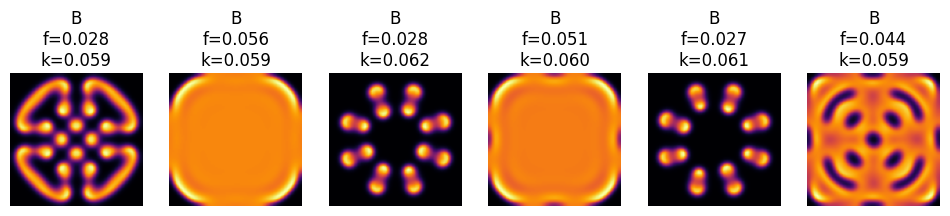


SYMBOL: C
count: 25
count       : 7.6000
avg_area    : 693.3402
roundness   : 0.7265
elongation  : 1.9767
density     : 0.3976
structure   : 0.0022
flow        : 0.0003


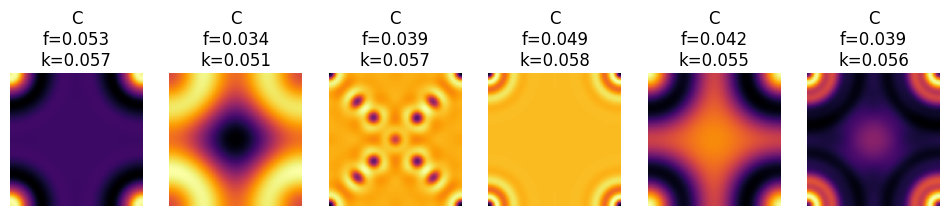


SYMBOL: D
count: 21
count       : 1.1905
avg_area    : 3334.9524
roundness   : 0.2200
elongation  : 1.0133
density     : 0.4000
structure   : 0.1124
flow        : 0.0208


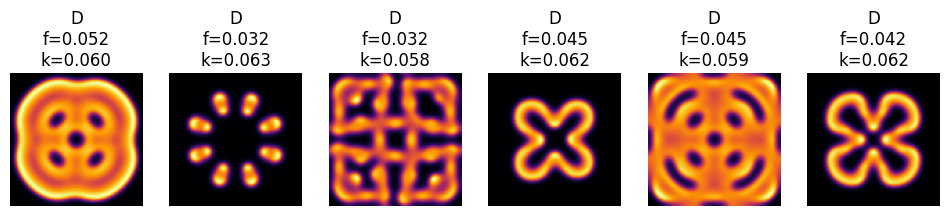


SYMBOL: E
count: 3
count       : 5.0000
avg_area    : 414.1905
roundness   : 0.8333
elongation  : 1.2028
density     : 0.2046
structure   : 0.0000
flow        : 0.0000


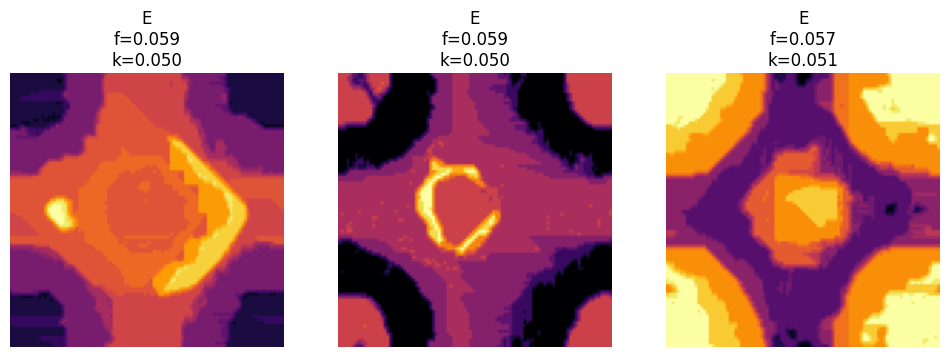

In [7]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for cluster_id in range(k):
    idxs = np.where(clusters == cluster_id)[0]

    print("\n====================")
    print("SYMBOL:", alphabet[cluster_id])
    print("count:", len(idxs))

    center = X[idxs].mean(axis=0)

    for name, val in zip(feature_names, center):
        print(f"{name:12}: {val:.4f}")

    show = idxs[:6]

    plt.figure(figsize=(12, 4))
    for j, idx in enumerate(show):
        plt.subplot(1, len(show), j + 1)
        plt.imshow(patterns[idx], cmap="inferno")
        plt.title(f"{alphabet[cluster_id]}\nf={params[idx][0]:.3f}\nk={params[idx][1]:.3f}")
        plt.axis("off")

    plt.show()

In [8]:
def auto_symbol(feed=0.035, kill=0.065, seed=999):
    A, B = run_gray_scott(feed=feed, kill=kill, seed=seed)
    f = pattern_features(B)

    x = np.array([[f[k] for k in feature_names]])
    x_scaled = scaler.transform(x)

    cluster_id = kmeans.predict(x_scaled)[0]
    symbol = alphabet[cluster_id]

    print("AUTO SYMBOL:", symbol)
    print("feed:", feed, "kill:", kill)

    for key, val in f.items():
        print(f"{key:12}: {val:.4f}" if isinstance(val, float) else f"{key:12}: {val}")

    plt.figure(figsize=(5, 5))
    plt.imshow(B, cmap="inferno")
    plt.title(f"Auto-symbol: {symbol}")
    plt.axis("off")
    plt.show()

    return symbol, f, B

AUTO SYMBOL: D
feed: 0.03 kill: 0.062
count       : 1
avg_area    : 3686.0000
roundness   : 0.1246
elongation  : 1.0031
density     : 0.4000
structure   : 0.1021
flow        : 0.0192


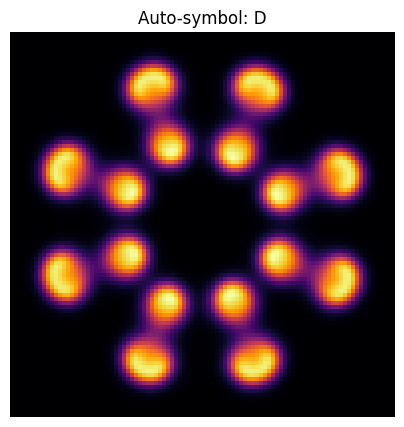

AUTO SYMBOL: D
feed: 0.055 kill: 0.062
count       : 1
avg_area    : 3686.0000
roundness   : 0.6301
elongation  : 1.0128
density     : 0.4000
structure   : 0.1245
flow        : 0.0149


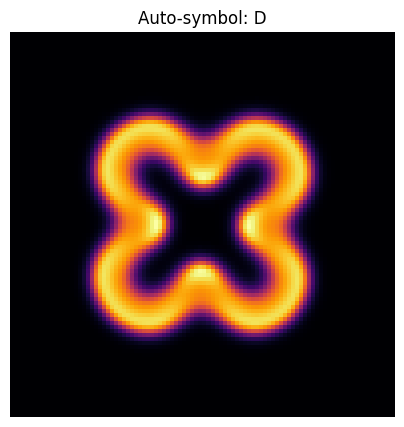

AUTO SYMBOL: D
feed: 0.025 kill: 0.055
count       : 2
avg_area    : 1843.0000
roundness   : 0.0755
elongation  : 1.0050
density     : 0.4000
structure   : 0.0914
flow        : 0.0275


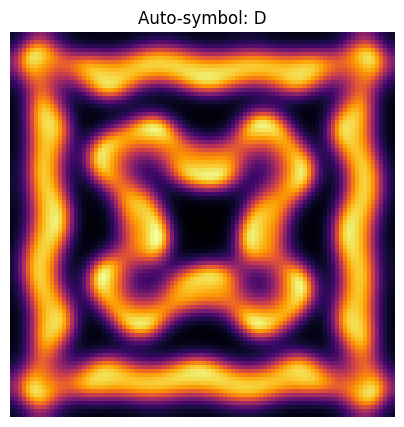

('D',
 {'count': 2,
  'avg_area': 1843.0,
  'roundness': 0.07553150103516507,
  'elongation': 1.0049546881016391,
  'density': 0.3999565972222222,
  'structure': 0.0914397164753788,
  'flow': 0.027513327248094608},
 array([[0.02555913, 0.03156167, 0.04318131, ..., 0.03979179, 0.02961454,
         0.02493132],
        [0.03116836, 0.03929533, 0.0544248 , ..., 0.04652099, 0.03480358,
         0.02972978],
        [0.04237258, 0.054093  , 0.07537204, ..., 0.06214727, 0.0465152 ,
         0.03994123],
        ...,
        [0.04104244, 0.04873191, 0.06556587, ..., 0.07386502, 0.05332094,
         0.04248755],
        [0.03042046, 0.03627641, 0.04884204, ..., 0.05319956, 0.03863794,
         0.03115791],
        [0.02532086, 0.03059979, 0.04139687, ..., 0.0419288 , 0.0308372 ,
         0.02538629]]))

In [9]:
auto_symbol(feed=0.030, kill=0.062)
auto_symbol(feed=0.055, kill=0.062)
auto_symbol(feed=0.025, kill=0.055)

In [10]:
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from skimage.morphology import skeletonize

In [11]:
def advanced_features(B):
    threshold = np.percentile(B, 60)
    binary = B > threshold

    filled = binary_fill_holes(binary)
    holes = filled.astype(int) - binary.astype(int)

    _, hole_count = nd_label(holes)

    skeleton = skeletonize(binary)
    skeleton_length = np.sum(skeleton)

    edge_density = np.mean(np.abs(laplacian(B)))

    cy, cx = np.array(B.shape) // 2
    y, x = np.indices(B.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    radial_profile = []
    for radius in range(5, int(B.shape[0] / 2), 5):
        mask = (r >= radius) & (r < radius + 5)
        radial_profile.append(np.mean(B[mask]))

    radial_profile = np.array(radial_profile)
    radial_symmetry = 1.0 / (1.0 + np.std(radial_profile))

    return {
        "holes": hole_count,
        "skeleton_length": float(skeleton_length),
        "edge_density": float(edge_density),
        "radial_symmetry": float(radial_symmetry),
    }

In [12]:
def sub_symbol_D(B):
    af = advanced_features(B)

    holes = af["holes"]
    skeleton_length = af["skeleton_length"]
    edge_density = af["edge_density"]
    radial_symmetry = af["radial_symmetry"]

    if holes >= 3 and radial_symmetry > 0.80:
        return "D1", "ring / mandala symmetry", af

    if skeleton_length > 600 and edge_density > 0.002:
        return "D2", "grid / labyrinth structure", af

    if radial_symmetry > 0.85:
        return "D3", "flower / radial lobe symmetry", af

    return "D0", "mixed symmetry", af

D samples: 21

---
sub-symbol: D1
meaning: ring / mandala symmetry
holes           : 6
skeleton_length : 512.0000
edge_density    : 0.0034
radial_symmetry : 0.9567


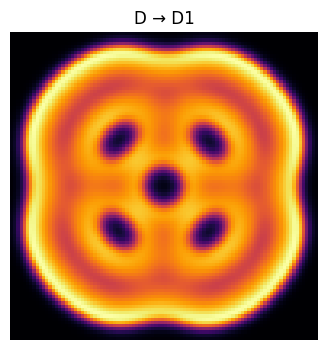


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 166.0000
edge_density    : 0.0020
radial_symmetry : 0.9414


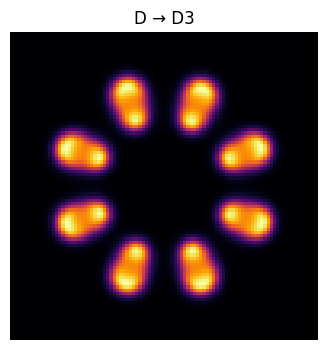


---
sub-symbol: D1
meaning: ring / mandala symmetry
holes           : 3
skeleton_length : 573.0000
edge_density    : 0.0043
radial_symmetry : 0.9612


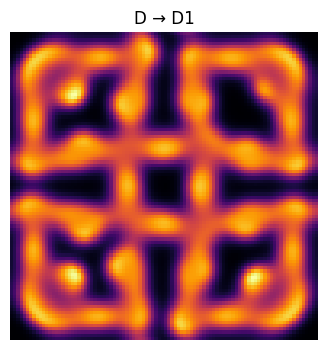


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 125.0000
edge_density    : 0.0024
radial_symmetry : 0.9244


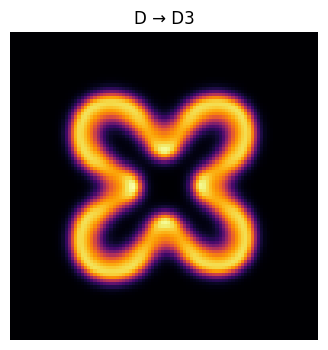


---
sub-symbol: D1
meaning: ring / mandala symmetry
holes           : 10
skeleton_length : 693.0000
edge_density    : 0.0034
radial_symmetry : 0.9651


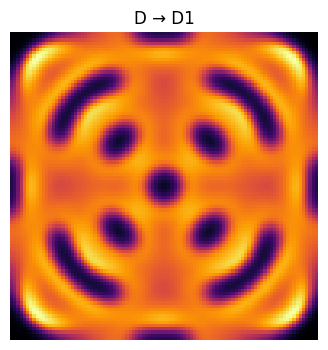


---
sub-symbol: D1
meaning: ring / mandala symmetry
holes           : 5
skeleton_length : 284.0000
edge_density    : 0.0030
radial_symmetry : 0.9355


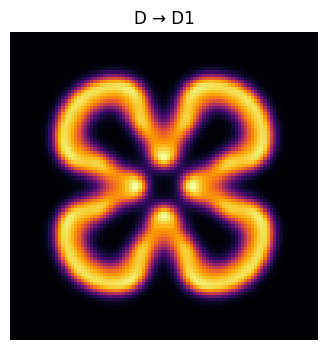


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 213.0000
edge_density    : 0.0026
radial_symmetry : 0.9445


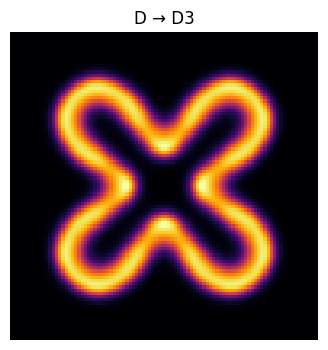


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 209.0000
edge_density    : 0.0023
radial_symmetry : 0.9325


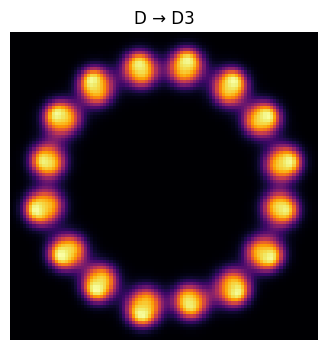


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 296.0000
edge_density    : 0.0032
radial_symmetry : 0.9575


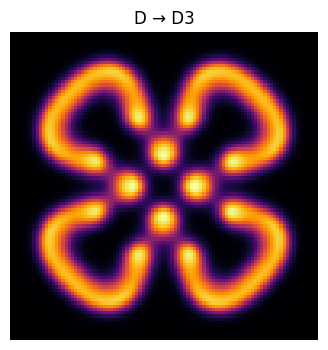


---
sub-symbol: D1
meaning: ring / mandala symmetry
holes           : 6
skeleton_length : 530.0000
edge_density    : 0.0040
radial_symmetry : 0.9568


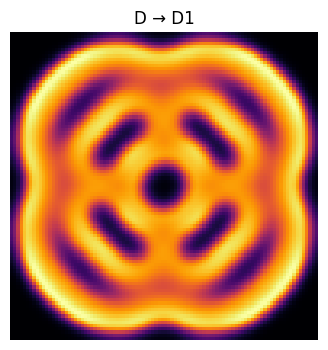


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 2
skeleton_length : 162.0000
edge_density    : 0.0024
radial_symmetry : 0.9333


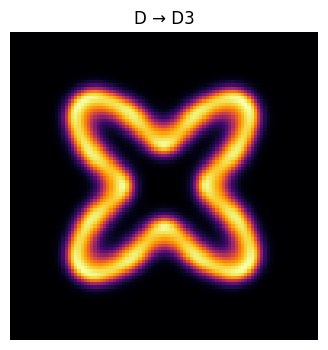


---
sub-symbol: D3
meaning: flower / radial lobe symmetry
holes           : 1
skeleton_length : 267.0000
edge_density    : 0.0029
radial_symmetry : 0.9559


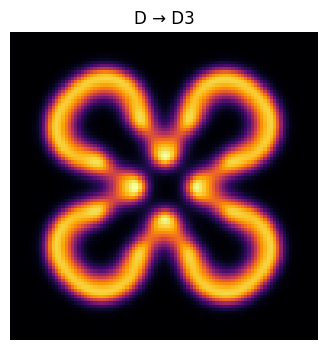

In [13]:
D_idxs = np.where(clusters == 3)[0]  # якщо D був SYMBOL D у клітині 7

print("D samples:", len(D_idxs))

for idx in D_idxs[:12]:
    B = patterns[idx]
    sub, meaning, af = sub_symbol_D(B)

    print("\n---")
    print("sub-symbol:", sub)
    print("meaning:", meaning)

    for k, v in af.items():
        print(f"{k:16}: {v:.4f}" if isinstance(v, float) else f"{k:16}: {v}")

    plt.figure(figsize=(4,4))
    plt.imshow(B, cmap="inferno")
    plt.title(f"D → {sub}")
    plt.axis("off")
    plt.show()

In [14]:
from sklearn.cluster import KMeans

def cluster_subD(patterns_D):
    feats = []

    for B in patterns_D:
        af = advanced_features(B)
        feats.append([
            af["holes"],
            af["skeleton_length"],
            af["edge_density"],
            af["radial_symmetry"]
        ])

    feats = np.array(feats)

    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(feats)

    return labels, feats

D subgroup: 1


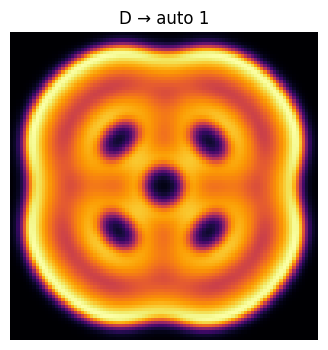

D subgroup: 0


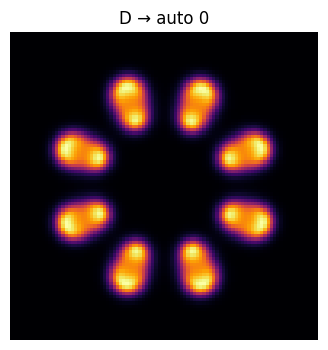

D subgroup: 1


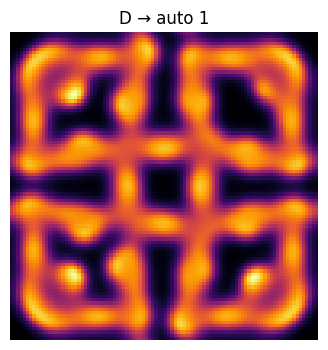

D subgroup: 0


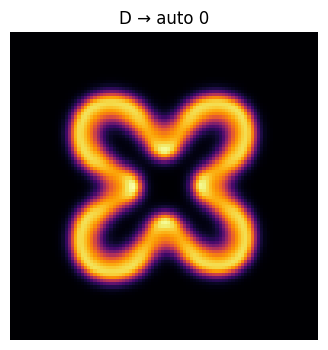

D subgroup: 2


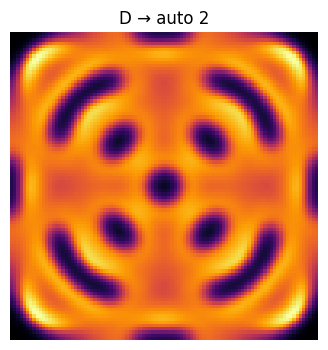

D subgroup: 0


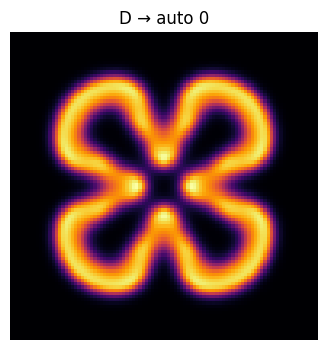

D subgroup: 0


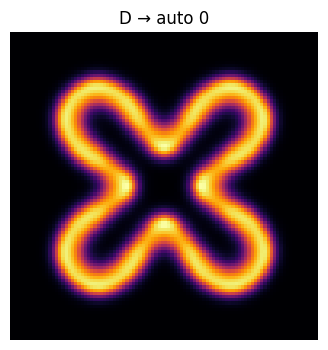

D subgroup: 0


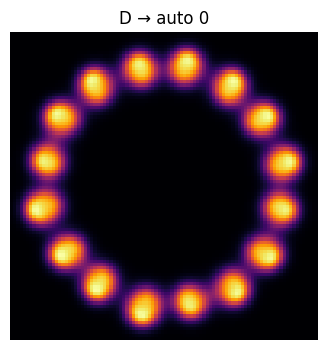

D subgroup: 0


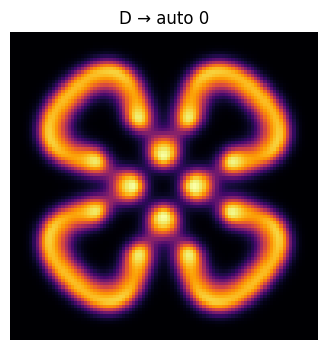

D subgroup: 1


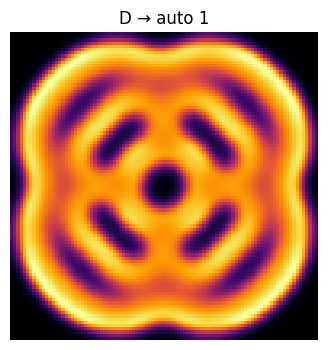

D subgroup: 0


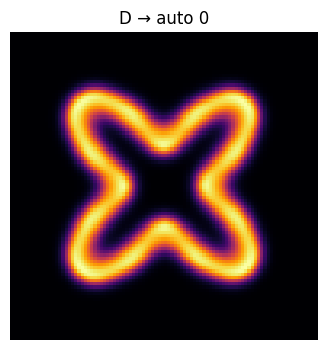

D subgroup: 0


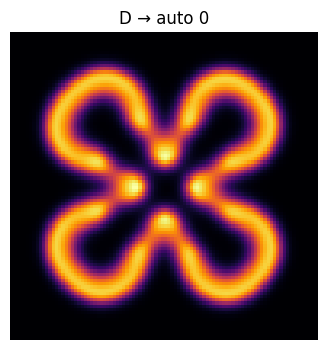

D subgroup: 0


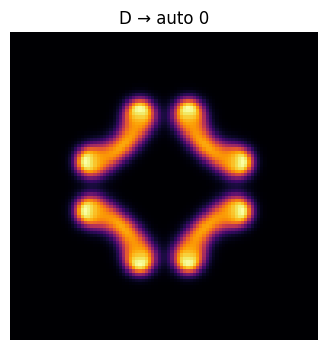

D subgroup: 0


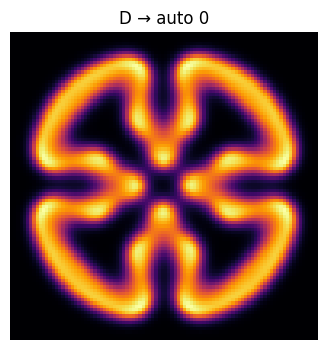

D subgroup: 0


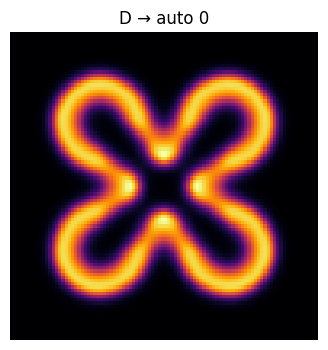

D subgroup: 0


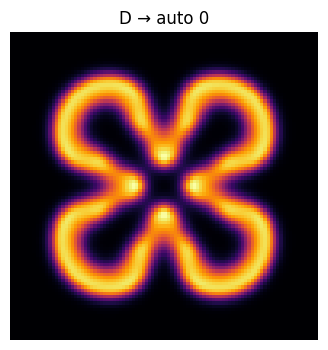

D subgroup: 0


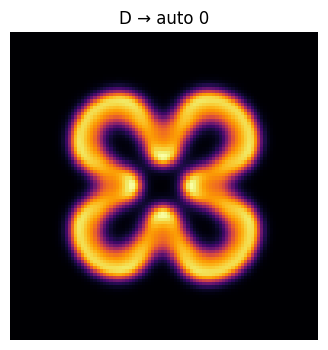

D subgroup: 0


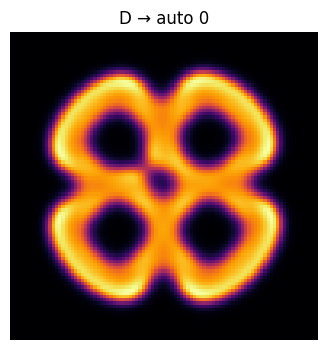

D subgroup: 0


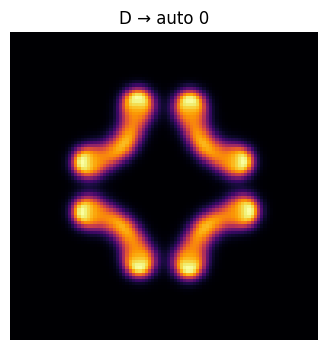

D subgroup: 0


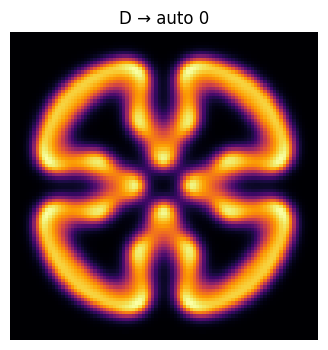

D subgroup: 0


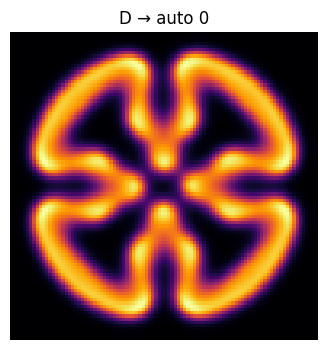

In [15]:
patterns_D = [patterns[i] for i in D_idxs]

labels, feats = cluster_subD(patterns_D)

for i, (B, lbl) in enumerate(zip(patterns_D, labels)):
    print("D subgroup:", lbl)

    plt.figure(figsize=(4,4))
    plt.imshow(B, cmap="inferno")
    plt.title(f"D → auto {lbl}")
    plt.axis("off")
    plt.show()

In [16]:
D_NAMES = {
    0: "D0_flower_radial_petals",
    1: "D1_mandala_ring_holes",
    2: "D2_grid_field_lattice",
}

D subgroup: D0_flower_radial_petals


Text(0.5, 1.0, 'D → D0_flower_radial_petals')

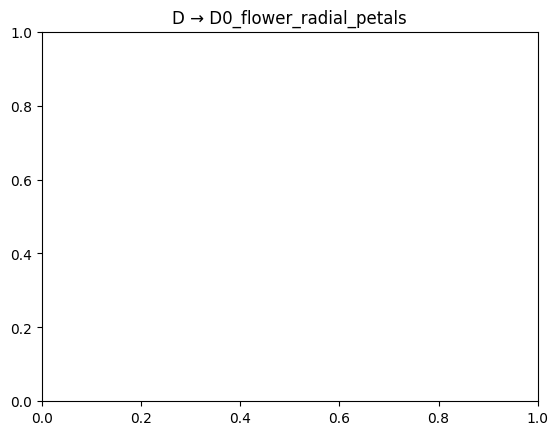

In [17]:
print("D subgroup:", D_NAMES[lbl])
plt.title(f"D → {D_NAMES[lbl]}")

In [18]:
import os
os.makedirs("reports", exist_ok=True)

In [19]:
with open("reports/diffusion_alphabet.md", "w") as f:
    f.write("# Diffusion Alphabet\n")

In [20]:
import os
os.path.exists("reports/diffusion_alphabet.md")

True

In [21]:
!git add .
!git commit -m "save work"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [22]:
V_MEMORY = []

def feature_vector(f):
    return np.array([f[k] for k in feature_names], dtype=float)

def store_memory(features, symbol, source="generated"):
    V_MEMORY.append({
        "vector": feature_vector(features),
        "features": features,
        "symbol": symbol,
        "source": source,
        "strength": 1.0,
    })

print("Memory initialized")

Memory initialized


In [23]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for i, f in enumerate(features):
    cluster_id = clusters[i]
    symbol = alphabet[cluster_id]
    store_memory(f, symbol, source=f"pattern_{i}")

print("Memory size:", len(V_MEMORY))

Memory size: 120


In [24]:
def bindu_decision(features, memory, allow_threshold=1.2, warn_threshold=2.2):
    current = feature_vector(features)

    distances = []

    for m in memory:
        d = np.linalg.norm(current - m["vector"])
        distances.append((d, m["symbol"], m))

    best_distance, best_symbol, best_memory = min(distances, key=lambda x: x[0])

    if best_distance < allow_threshold:
        action = "ALLOW"
    elif best_distance < warn_threshold:
        action = "WARN"
    else:
        action = "MUTATE"

    return {
        "action": action,
        "matched_symbol": best_symbol,
        "distance": best_distance,
        "memory_source": best_memory["source"],
    }

In [25]:
def run_vkernel_pipeline(feed=0.035, kill=0.065, seed=999):
    A, B = run_gray_scott(feed=feed, kill=kill, seed=seed)

    f = pattern_features(B)

    x = np.array([[f[k] for k in feature_names]])
    x_scaled = scaler.transform(x)

    cluster_id = kmeans.predict(x_scaled)[0]
    symbol = alphabet[cluster_id]

    decision = bindu_decision(f, V_MEMORY)

    print("\n=== V-KERNEL PIPELINE ===")
    print("feed:", feed, "kill:", kill, "seed:", seed)
    print("symbol:", symbol)
    print("action:", decision["action"])
    print("matched_symbol:", decision["matched_symbol"])
    print("distance:", round(decision["distance"], 4))
    print("memory:", decision["memory_source"])

    print("\nFeatures:")
    for k, v in f.items():
        print(f"{k:12}: {v:.4f}" if isinstance(v, float) else f"{k:12}: {v}")

    plt.figure(figsize=(5, 5))
    plt.imshow(B, cmap="inferno")
    plt.title(f"{symbol} → {decision['action']}")
    plt.axis("off")
    plt.show()

    return {
        "field": B,
        "features": f,
        "symbol": symbol,
        "decision": decision,
    }


=== V-KERNEL PIPELINE ===
feed: 0.03 kill: 0.062 seed: 1001
symbol: D
action: ALLOW
matched_symbol: D
distance: 0.0134
memory: pattern_77

Features:
count       : 1
avg_area    : 3686.0000
roundness   : 0.1267
elongation  : 1.0048
density     : 0.4000
structure   : 0.1021
flow        : 0.0192


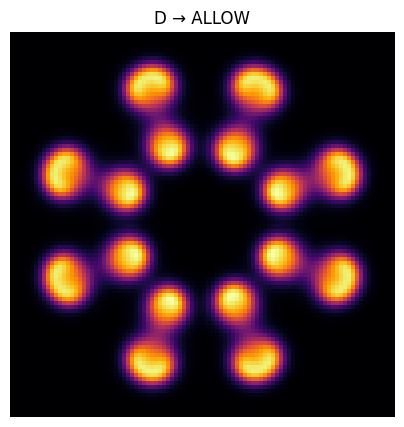


=== V-KERNEL PIPELINE ===
feed: 0.055 kill: 0.062 seed: 1002
symbol: D
action: ALLOW
matched_symbol: A
distance: 0.0515
memory: pattern_3

Features:
count       : 1
avg_area    : 3686.0000
roundness   : 0.6274
elongation  : 1.0178
density     : 0.4000
structure   : 0.1237
flow        : 0.0145


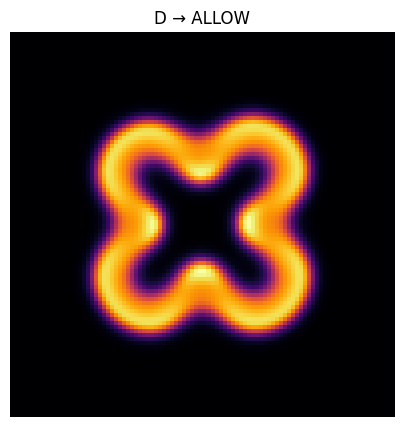


=== V-KERNEL PIPELINE ===
feed: 0.025 kill: 0.055 seed: 1003
symbol: D
action: ALLOW
matched_symbol: B
distance: 0.477
memory: pattern_30

Features:
count       : 3
avg_area    : 1228.6667
roundness   : 0.1613
elongation  : 1.4443
density     : 0.4000
structure   : 0.0927
flow        : 0.0276


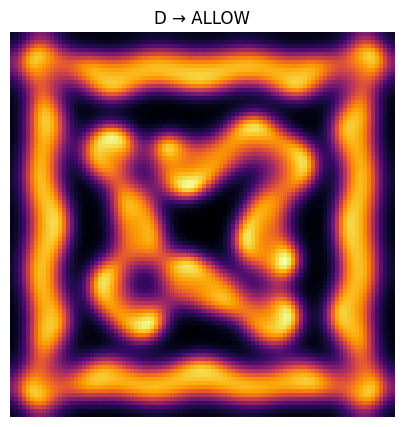

In [26]:
result_1 = run_vkernel_pipeline(feed=0.030, kill=0.062, seed=1001)
result_2 = run_vkernel_pipeline(feed=0.055, kill=0.062, seed=1002)
result_3 = run_vkernel_pipeline(feed=0.025, kill=0.055, seed=1003)

In [27]:
def feedback_update(result):
    action = result["decision"]["action"]

    if action == "ALLOW":
        store_memory(result["features"], result["symbol"], source="feedback_allow")
        print("Stored stable pattern in memory")

    elif action == "WARN":
        store_memory(result["features"], result["symbol"], source="feedback_warn")
        print("Stored warning pattern with lower confidence")

    elif action == "MUTATE":
        print("Pattern too far from memory. Mutation suggested.")

feedback_update(result_1)
feedback_update(result_2)
feedback_update(result_3)

print("Updated memory size:", len(V_MEMORY))

Stored stable pattern in memory
Stored stable pattern in memory
Stored stable pattern in memory
Updated memory size: 123
